In [2]:
import MDAnalysis as mda
from MDAnalysis.transformations import unwrap, center_in_box, wrap
import py3Dmol
import matplotlib.pyplot as plt

In [1]:
import MDAnalysis as mda
import numpy as np
import pandas as pd
from collections import defaultdict

# Three replicas, each containing POPC100, POPC75, POPC50 subfolders
replicas = ["sim_1", "sim_2", "sim_3"]
systems  = ["POPC100", "POPC75", "POPC50"]

cutoff = 10.0  # in Angstroms
overall_stats = []
all_residue_frequencies = []
residue_type_counts_all = []

for system in systems:
    print(f"Processing {system} across replicas...")

    top_file = f"./{replicas[0]}/{system}/md.gro"

    traj_files = [f"./{rep}/{system}/md.xtc" for rep in replicas]

    # Create a single Universe with concatenated trajectories
    u = mda.Universe(top_file, traj_files)

    protein = u.select_atoms("protein")
    lipid_heads = u.select_atoms("name PO4")

    residue_frame_counts = defaultdict(int)
    residue_types = {}
    total_frames = 0

    for ts in u.trajectory:
        total_frames += 1
        dists = mda.lib.distances.distance_array(protein.positions, lipid_heads.positions)
        close_protein_indices = np.any(dists < cutoff, axis=1)
        nearby_residues = protein[close_protein_indices].residues

        for res in nearby_residues:
            if res.resid != -1:
                key = (res.resid, res.resname)
                residue_frame_counts[key] += 1
                residue_types[key] = res.resname

    # Per-residue frequency (now over all 3 replicas concatenated)
    res_freq_data = []
    type_count = defaultdict(int)

    for (resid, resname), count in residue_frame_counts.items():
        freq = count / total_frames
        res_freq_data.append({
            'resid': resid,
            'resname': resname,
            'frequency': freq,
            'system': system,   # label by POPC100 / POPC75 / POPC50
        })
        type_count[resname] += 1

    all_residue_frequencies.extend(res_freq_data)
    type_count["system"] = system
    residue_type_counts_all.append(type_count)

df_per_residue = pd.DataFrame(all_residue_frequencies)
df_per_type = pd.DataFrame(residue_type_counts_all).fillna(0)

df_per_residue.to_csv("per_residue_contact_frequencies.csv", index=False)
df_per_type.to_csv("residue_type_counts_by_system.csv", index=False)


Processing POPC100 across replicas...


/home/mjianming/miniconda3/envs/ELP/lib/python3.8/site-packages/MDAnalysis/topology/guessers.py:146: UserWarning: Failed to guess the mass for the following atom types: D
  warnings.warn("Failed to guess the mass for the following atom types: {}".format(atom_type))
/home/mjianming/miniconda3/envs/ELP/lib/python3.8/site-packages/MDAnalysis/topology/guessers.py:146: UserWarning: Failed to guess the mass for the following atom types: G
  warnings.warn("Failed to guess the mass for the following atom types: {}".format(atom_type))
/home/mjianming/miniconda3/envs/ELP/lib/python3.8/site-packages/MDAnalysis/coordinates/XDR.py:241: UserWarning: Reload offsets from trajectory
 ctime or size or n_atoms did not match
  warnings.warn("Reload offsets from trajectory\n "


Processing POPC75 across replicas...
Processing POPC50 across replicas...


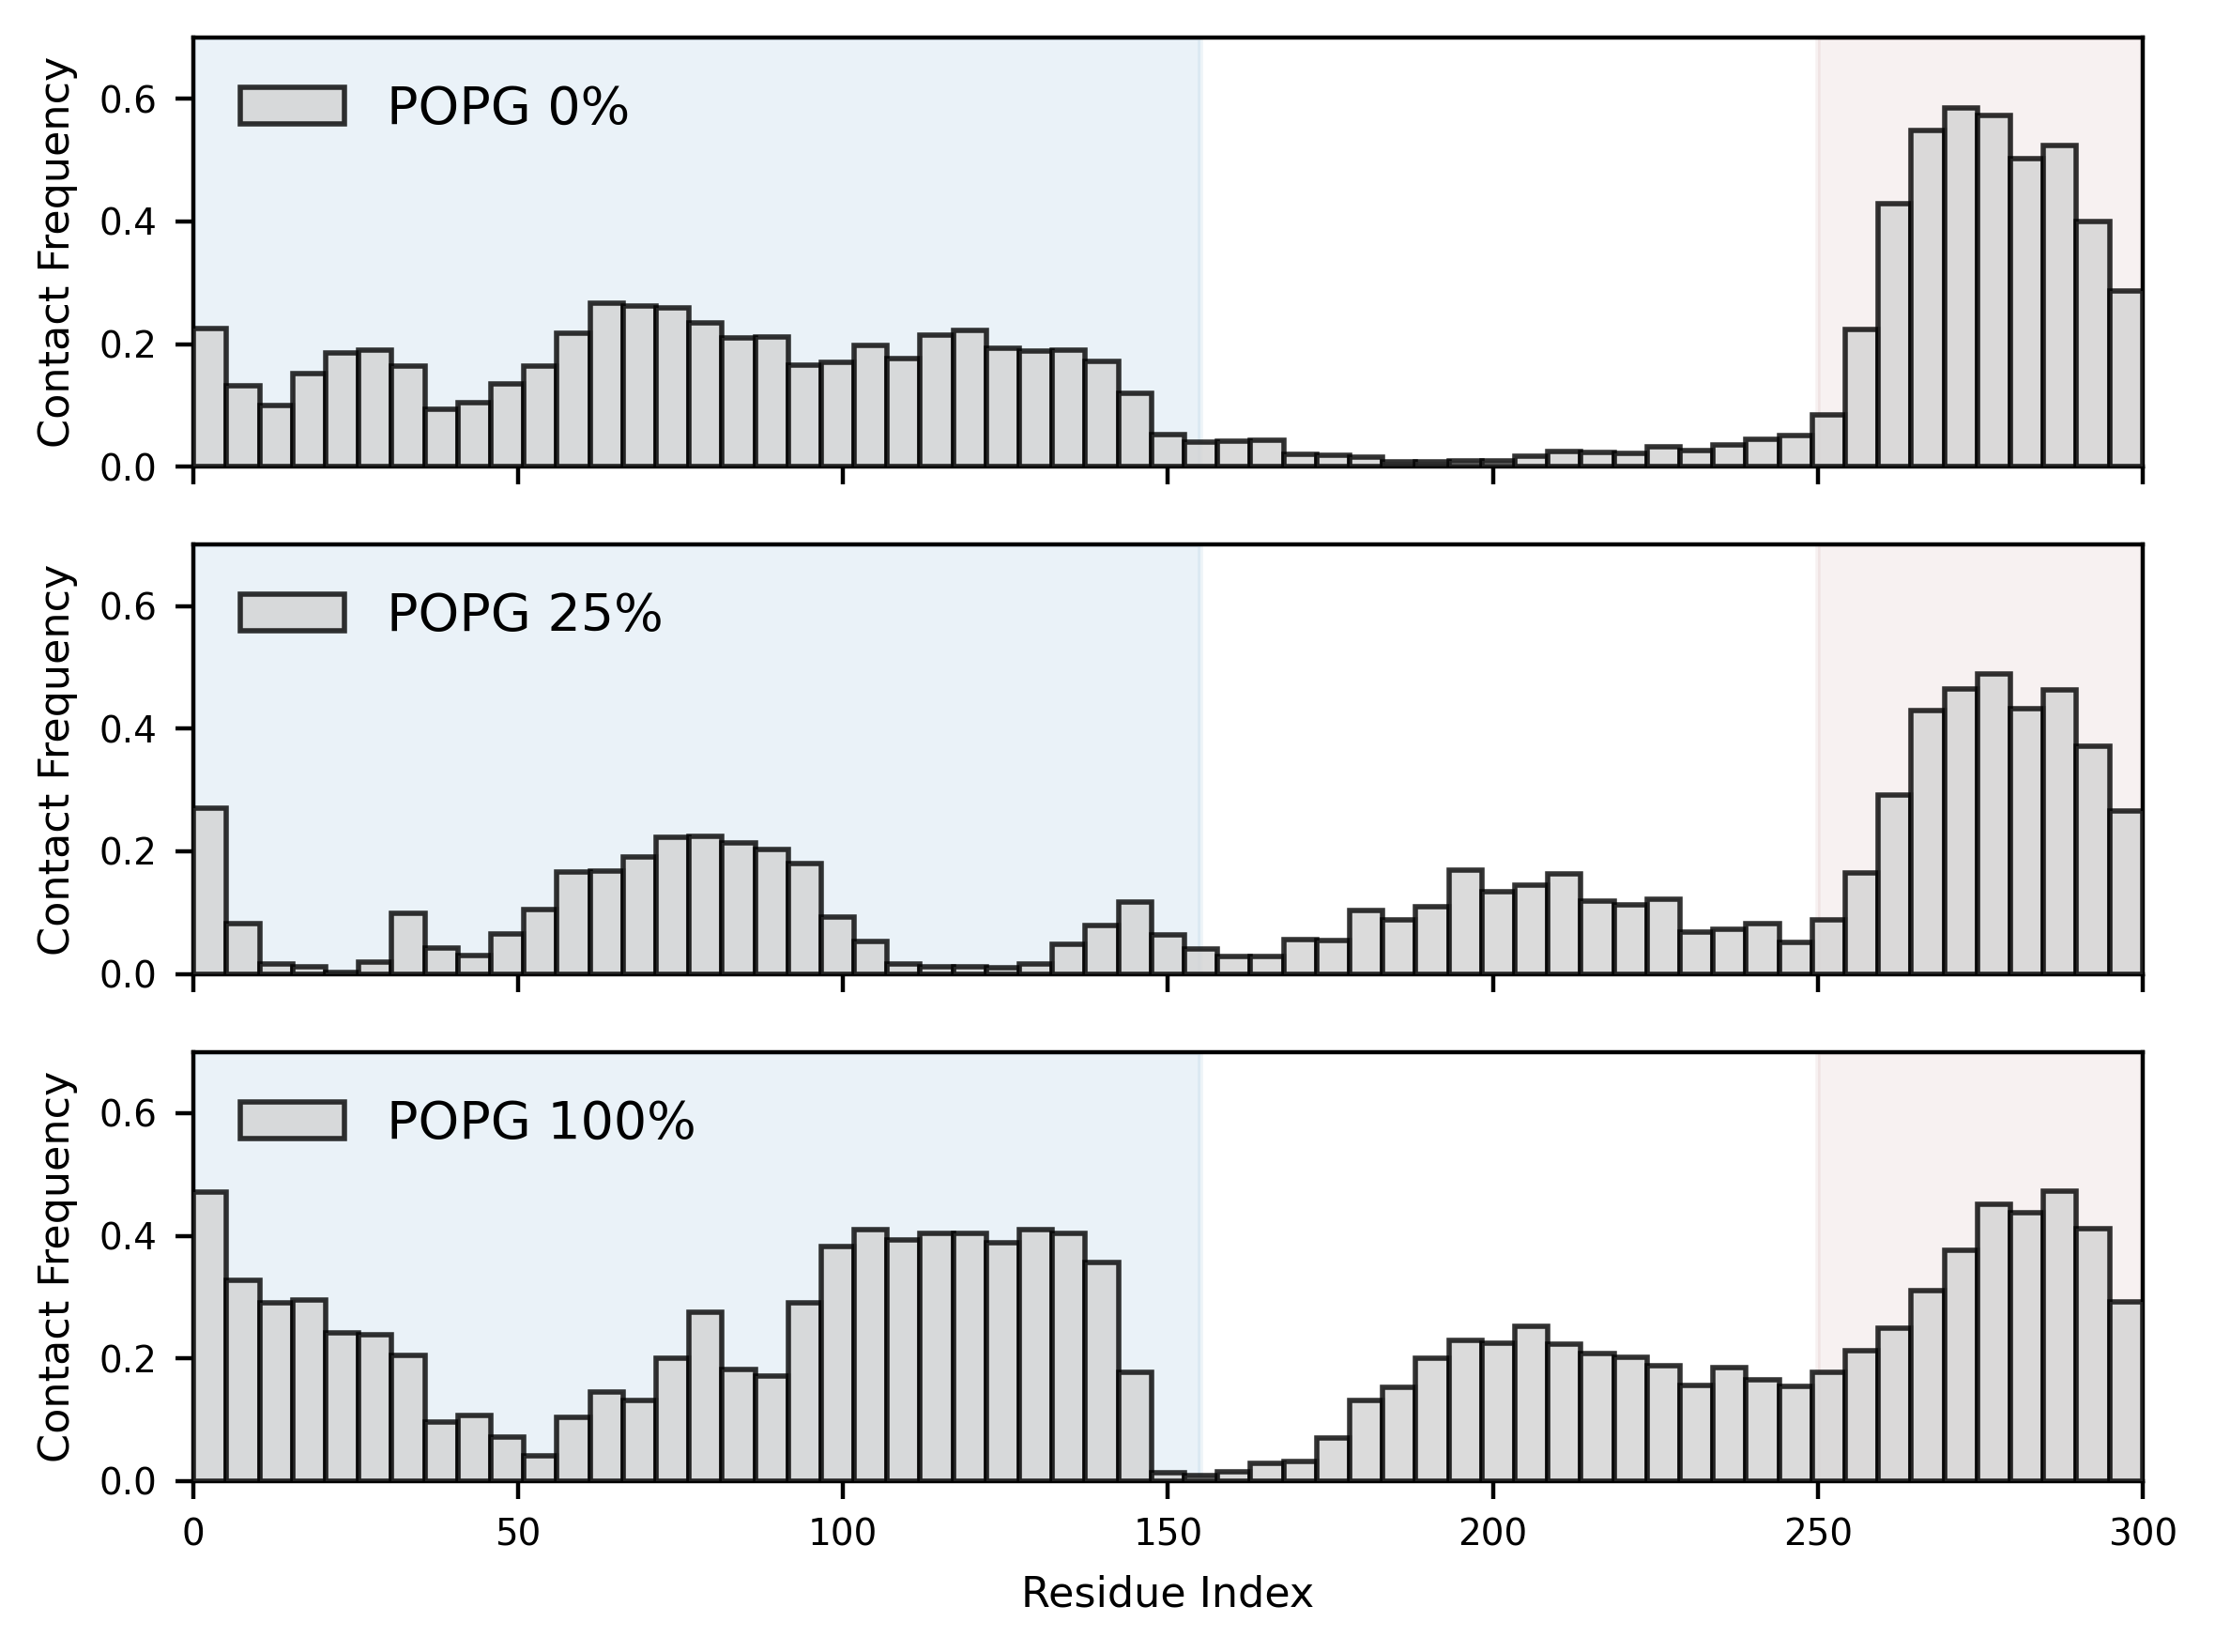

In [15]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

per_system_dfs = {
    system: df_per_residue[df_per_residue["system"] == system].copy()
    for system in systems
}

# Make sure resid is numeric
for df in per_system_dfs.values():
    df["resid"] = pd.to_numeric(df["resid"], errors="coerce")

# Use smallest residue id as reference (so N-term ~ 0)
starting = min(df["resid"].min() for df in per_system_dfs.values())

labels = ['POPG 0%', 'POPG 25%', 'POPG 50%']

# Bins along residue index
bins = np.linspace(0, 300, 60)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_width = bins[1] - bins[0]

n_sys = len(systems)

fig, axes = plt.subplots(
    nrows=n_sys,
    ncols=1,
    figsize=(6, 1.5 * n_sys),
    dpi=400,
    sharex=True
)

# In case n_sys == 1, axes is not an array
if n_sys == 1:
    axes = [axes]

for ax, system, label in zip(axes, systems, labels):
    subset = per_system_dfs[system].copy()

    shifted_resid = subset["resid"] - starting

    # Sum of frequencies in each bin
    sum_freq, _ = np.histogram(
        shifted_resid,
        bins=bins,
        weights=subset["frequency"]
    )

    # Number of residues in each bin
    n_res, _ = np.histogram(shifted_resid, bins=bins)

    # Mean frequency per residue in each bin (avoid divide-by-zero)
    mean_freq = np.divide(
        sum_freq,
        n_res,
        out=np.zeros_like(sum_freq, dtype=float),
        where=n_res > 0
    )

    # Bar plot: x = residue index bin, y = mean contact frequency
    ax.bar(
        bin_centers,
        mean_freq,
        width=bin_width,
        color="lightgray",
        alpha=0.8,
        edgecolor="k",
        zorder=4,
        label=label
    )

    # Domain shading (tune boundaries to your actual domains)
    ax.axvspan(0,   155, color="#3688bb", alpha=0.1)   # N-Term
    ax.axvspan(155, 250, color="white",   alpha=0.1)   # Linker
    ax.axvspan(250, 300, color="#b57979", alpha=0.1)   # C-Term

    ymax = mean_freq.max() if mean_freq.size > 0 else 0
    if ymax == 0:
        ymax = 1.0
    ymax *= 1.1

    ax.set_xlim(0, 300)
    ax.set_ylim(0, 0.7)

    ax.set_ylabel("Contact Frequency", fontsize=8)
    #ax.set_title(system, fontsize=9)
    ax.tick_params(labelsize=7)
    ax.legend(frameon=False)

# Common x-label at the bottom
axes[-1].set_xlabel("Residue Index", fontsize=8)

plt.tight_layout()
plt.savefig('./charge_popc.pdf', dpi=600, bbox_inches='tight')
plt.show()